# Model Training - AQI Shift Classification
Train Random Forest and XGBoost on shift-level processed data.

In [15]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import lightgbm as lgb
from xgboost import XGBClassifier

PROCESSED_PATH = '/kaggle/input/datasets/nguynhonggiahuy/hcmc-processed-data-v1/processed_data.csv'
df = pd.read_csv(PROCESSED_PATH)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Date', 'Shift']).reset_index(drop=True)

print('Original shape:', df.shape)
print('\nFirst few rows:')
display(df.head())

Original shape: (8814, 28)

First few rows:


,Date,Shift,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_direction_10m,surface_pressure,precipitation,cloud_cover,pm2_5,...,pm2_5_lag_3,pm2_5_lag_6,temperature_2m_lag_1,temperature_2m_lag_2,temperature_2m_lag_3,temperature_2m_lag_6,AQI_Class_lag_1,AQI_Class_lag_2,AQI_Class_lag_3,AQI_Class_lag_6
0,2018-01-03,Afternoon,31.683333,53.833333,7.650000,174.666667,1005.783333,0.0,27.333333,28.1,...,28.1,28.1,24.200000,24.500000,30.266667,29.000000,1.0,1.0,1.0,1.0
1,2018-01-03,Morning,26.383333,73.000000,5.483333,138.666667,1008.583333,0.0,45.666667,28.1,...,28.1,28.1,31.683333,24.200000,24.500000,24.700000,1.0,1.0,1.0,1.0
2,2018-01-03,Night,24.850000,84.416667,7.725000,269.333333,1007.850000,0.0,88.750000,28.1,...,28.1,28.1,26.383333,31.683333,24.200000,23.908333,1.0,1.0,1.0,1.0
3,2018-01-04,Afternoon,32.333333,47.666667,4.016667,120.666667,1006.033333,0.0,94.166667,28.1,...,28.1,28.1,24.850000,26.383333,31.683333,30.266667,1.0,1.0,1.0,1.0
4,2018-01-04,Morning,27.316667,72.833333,5.416667,178.666667,1008.850000,0.0,59.666667,28.1,...,28.1,28.1,32.333333,24.850000,26.383333,24.500000,1.0,1.0,1.0,1.0


In [16]:
# Step 2: Train-Test Split (Strict Time-Series Rule)
# Extract Date and Shift for later reconstruction
meta_cols = df[['Date', 'Shift']].copy()

# Identify target and features
target_col = 'AQI_Class'
y = df[target_col].copy()

# Drop leakage columns: Date, Shift, target, and pm2_5 (target is derived from pm2_5)
X = df.drop(columns=['Date', 'Shift', target_col, 'pm2_5']).copy()

print('Feature shape:', X.shape)
print('Target shape:', y.shape)
print('Features:', X.columns.tolist())

# Temporal split (80/20), no shuffle - BEFORE SMOTE
split_idx = int(len(df) * 0.8)

X_train = X.iloc[:split_idx].copy()
X_test = X.iloc[split_idx:].copy()
y_train = y.iloc[:split_idx].copy()
y_test = y.iloc[split_idx:].copy()
meta_test = meta_cols.iloc[split_idx:].reset_index(drop=True)

print(f'\nTrain size: {len(X_train)}')
print(f'Test size: {len(X_test)}')
print(f'\nTraining set class distribution:\n{y_train.value_counts().sort_index()}')
print(f'\nTest set class distribution:\n{y_test.value_counts().sort_index()}')

Feature shape: (8814, 24)
Target shape: (8814,)
Features: ['temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 'wind_direction_10m', 'surface_pressure', 'precipitation', 'cloud_cover', 'pm10', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'pm2_5_lag_1', 'pm2_5_lag_2', 'pm2_5_lag_3', 'pm2_5_lag_6', 'temperature_2m_lag_1', 'temperature_2m_lag_2', 'temperature_2m_lag_3', 'temperature_2m_lag_6', 'AQI_Class_lag_1', 'AQI_Class_lag_2', 'AQI_Class_lag_3', 'AQI_Class_lag_6']

Train size: 7051
Test size: 1763

Training set class distribution:
AQI_Class
0      60
1    6403
2     588
Name: count, dtype: int64

Test set class distribution:
AQI_Class
0     20
1    956
2    787
Name: count, dtype: int64


In [17]:
# Step 3: Handle Imbalance with SMOTE (Training Set Only)
# Apply SMOTE to oversample minority classes in training set only
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print('SMOTE applied to training set.')
print(f'X_train shape after SMOTE: {X_train_smote.shape}')
print(f'y_train distribution after SMOTE:\n{pd.Series(y_train_smote).value_counts().sort_index()}')
print('\nTest set remains untouched (no SMOTE applied).')

SMOTE applied to training set.
X_train shape after SMOTE: (19209, 24)
y_train distribution after SMOTE:
AQI_Class
0    6403
1    6403
2    6403
Name: count, dtype: int64

Test set remains untouched (no SMOTE applied).


In [18]:
# Step 4: Model Initialization & Training
# Since we used SMOTE, we do not need class_weight='balanced' anymore

# Baseline: Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr_model.fit(X_train_smote, y_train_smote)
print('Logistic Regression trained.')

# Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_smote, y_train_smote)
print('Random Forest trained.')

# LightGBM Classifier
lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=7,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgb_model.fit(X_train_smote, y_train_smote)
print('LightGBM trained.')

# XGBoost Classifier
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    objective='multi:softmax',
    num_class=len(np.unique(y_train_smote)),
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train_smote, y_train_smote)
print('XGBoost trained.')

# Voting Classifier (combining RF, LightGBM, and XGBoost)
voting_model = VotingClassifier(
    estimators=[
        ('rf', rf_model),
        ('lgb', lgb_model),
        ('xgb', xgb_model)
    ],
    voting='soft'
)
voting_model.fit(X_train_smote, y_train_smote)
print('Voting Classifier trained.')

print('\nAll models training complete.')

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression trained.
Random Forest trained.
LightGBM trained.
XGBoost trained.
Voting Classifier trained.

All models training complete.


Logistic Regression
Accuracy: 0.7975

Classification Report:
              precision    recall  f1-score   support

           0     0.4516    0.7000    0.5490        20
           1     0.7360    0.9770    0.8396       956
           2     0.9892    0.5820    0.7328       787

    accuracy                         0.7975      1763
   macro avg     0.7256    0.7530    0.7071      1763
weighted avg     0.8458    0.7975    0.7886      1763

Random Forest
Accuracy: 0.8054

Classification Report:
              precision    recall  f1-score   support

           0     0.3571    0.5000    0.4167        20
           1     0.7434    0.9791    0.8451       956
           2     0.9958    0.6023    0.7506       787

    accuracy                         0.8054      1763
   macro avg     0.6988    0.6938    0.6708      1763
weighted avg     0.8517    0.8054    0.7981      1763

LightGBM
Accuracy: 0.7731

Classification Report:
              precision    recall  f1-score   support

           0     

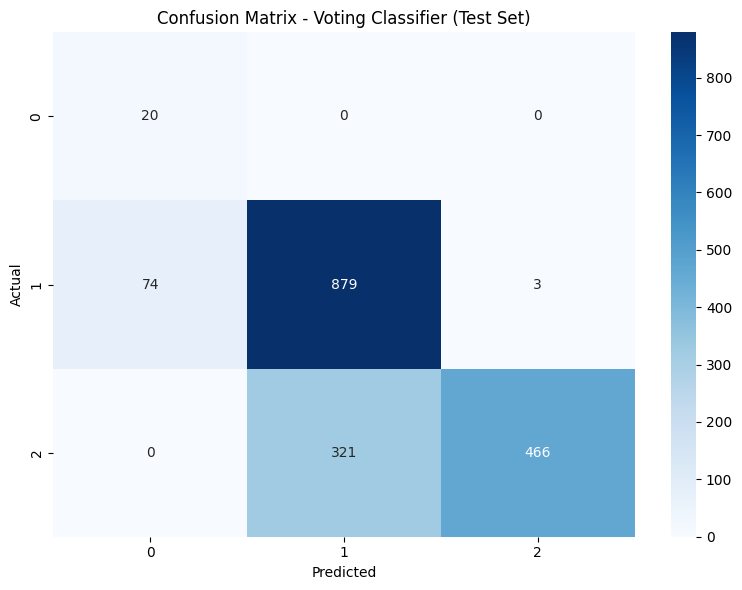


Model Performance Summary:
Logistic Regression: 0.7975
Random Forest: 0.8054
LightGBM: 0.7731
XGBoost: 0.7731
Voting Classifier: 0.7742


In [19]:
# Step 5: Evaluation - Predict on untouched test set
models = {
    'Logistic Regression': lr_model,
    'Random Forest': rf_model,
    'LightGBM': lgb_model,
    'XGBoost': xgb_model,
    'Voting Classifier': voting_model
}

results = {}

for model_name, model in models.items():
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    
    print(f'{model_name}')
    print(f'Accuracy: {acc:.4f}')
    print('\nClassification Report:')
    print(classification_report(y_test, preds, digits=4))
    
    results[model_name] = {
        'accuracy': acc,
        'predictions': preds
    }

# Plot Confusion Matrix for Voting Classifier
voting_preds = voting_model.predict(X_test)
cm = confusion_matrix(y_test, voting_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title('Confusion Matrix - Voting Classifier (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print('\n' + '='*50)
print('Model Performance Summary:')
print('='*50)
for model_name, result in results.items():
    print(f'{model_name}: {result["accuracy"]:.4f}')

In [20]:
# Step 6: Export for Web App

# Programmatically identify the best model based on highest accuracy
best_model_name = max(results, key=lambda k: results[k]['accuracy'])
best_model = models[best_model_name]
best_accuracy = results[best_model_name]['accuracy']

print(f'Best Model: {best_model_name}')
print(f'Test Accuracy: {best_accuracy:.4f}')

# Save the best trained model
joblib.dump(best_model, 'aqi_model.pkl')
print(f'\nSaved best model: aqi_model.pkl ({best_model_name})')

# Reconstruct Test Set with predictions from best model
demo_data = pd.DataFrame()
demo_data['Date'] = meta_test['Date'].values
demo_data['Shift'] = meta_test['Shift'].values

# Add all original features from X_test
for col in X_test.columns:
    demo_data[col] = X_test[col].values

# Add actual target and best model predictions
demo_data['AQI_Class_Actual'] = y_test.values
demo_data['AQI_Class_Predicted'] = best_model.predict(X_test)

# Save to CSV
demo_data.to_csv('demo_forecast_data.csv', index=False)

print(f'Saved test set with predictions: demo_forecast_data.csv')
print(f'\nDemo data shape: {demo_data.shape}')
print('\nFirst few rows:')
display(demo_data.head(10))

Best Model: Random Forest
Test Accuracy: 0.8054

Saved best model: aqi_model.pkl (Random Forest)
Saved test set with predictions: demo_forecast_data.csv

Demo data shape: (1763, 28)

First few rows:


,Date,Shift,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_direction_10m,surface_pressure,precipitation,cloud_cover,pm10,...,temperature_2m_lag_1,temperature_2m_lag_2,temperature_2m_lag_3,temperature_2m_lag_6,AQI_Class_lag_1,AQI_Class_lag_2,AQI_Class_lag_3,AQI_Class_lag_6,AQI_Class_Actual,AQI_Class_Predicted
0,2024-06-10,Morning,28.616667,79.833333,11.783333,233.166667,1009.483333,0.033333,96.000000,37.1,...,27.750000,26.566667,28.916667,29.483333,1.0,2.0,2.0,2.0,1,1
1,2024-06-10,Night,26.141667,88.416667,7.141667,189.750000,1009.125000,0.000000,99.000000,59.8,...,28.616667,27.750000,26.566667,26.483333,1.0,1.0,2.0,2.0,2,2
2,2024-06-11,Afternoon,31.683333,65.000000,14.716667,247.500000,1008.133333,0.066667,84.166667,41.0,...,26.141667,28.616667,27.750000,28.216667,2.0,1.0,1.0,1.0,1,1
3,2024-06-11,Morning,29.016667,75.833333,8.116667,198.166667,1011.116667,0.016667,25.666667,48.3,...,31.683333,26.141667,28.616667,28.916667,1.0,2.0,1.0,2.0,1,1
4,2024-06-11,Night,26.916667,85.916667,6.558333,200.500000,1009.700000,0.000000,85.250000,59.8,...,29.016667,31.683333,26.141667,26.566667,1.0,1.0,2.0,2.0,2,2
5,2024-06-12,Afternoon,31.716667,67.333333,11.850000,281.666667,1008.700000,0.366667,87.000000,35.2,...,26.916667,29.016667,31.683333,27.750000,2.0,1.0,1.0,1.0,1,1
6,2024-06-12,Morning,29.300000,75.333333,7.350000,281.666667,1011.566667,0.016667,62.833333,28.4,...,31.716667,26.916667,29.016667,28.616667,1.0,2.0,1.0,1.0,1,1
7,2024-06-12,Night,27.225000,84.333333,7.550000,254.000000,1009.366667,0.000000,78.583333,45.9,...,29.300000,31.716667,26.916667,26.141667,1.0,1.0,2.0,2.0,1,1
8,2024-06-13,Afternoon,33.283333,60.333333,14.450000,291.500000,1005.916667,0.300000,79.333333,41.0,...,27.225000,29.300000,31.716667,31.683333,1.0,1.0,1.0,1.0,1,1
9,2024-06-13,Morning,29.766667,76.166667,10.716667,292.833333,1009.666667,0.033333,62.000000,37.3,...,33.283333,27.225000,29.300000,29.016667,1.0,1.0,1.0,1.0,1,1
